In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA = '/content/drive/MyDrive/Fetch SQL Files/'

In [4]:
df = pd.read_csv(DATA + 'vw_join_items_returns.csv')

In [5]:
df.head(30)

,order_id,order_item_id,product_id,seller_id,product_category,price_brl,freight_brl,return_id,return_reason,return_requested_date,return_completed_date,refund_amount_brl,restocked,is_returned
0,7f39ba4c9052be115350065d07583cac,1,a2ff5a97bf95719e38ea2e3b4105bce8,0015a82c2db000af6aaaf3ae2ecb0532,Small Appliances,895.0,21.02,NaN,NaN,NaN,NaN,NaN,NaN,False
1,9dc8d1a6f16f1b89874c29c9d8d30447,1,a2ff5a97bf95719e38ea2e3b4105bce8,0015a82c2db000af6aaaf3ae2ecb0532,Small Appliances,895.0,21.02,NaN,NaN,NaN,NaN,NaN,NaN,False
2,d455a8cb295653b55abda06d434ab492,1,a2ff5a97bf95719e38ea2e3b4105bce8,0015a82c2db000af6aaaf3ae2ecb0532,Small Appliances,895.0,21.02,NaN,NaN,NaN,NaN,NaN,NaN,False
3,006e43460a55bc60c0a437521e426529,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,Garden Tools,99.0,43.06,NaN,NaN,NaN,NaN,NaN,NaN,False
4,038345c4a9d21c17180f2f77e1701c69,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,Garden Tools,99.0,33.08,NaN,NaN,NaN,NaN,NaN,NaN,False
5,06c07d5b2696b9631375e2877c955b3b,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,Garden Tools,99.0,33.08,NaN,NaN,NaN,NaN,NaN,NaN,False
6,077934ed5527f66c12ae98ad498190e1,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,Garden Tools,89.0,34.99,NaN,NaN,NaN,NaN,NaN,NaN,False
7,07dba073c2b18c2c748f28ed51c87ee8,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,Garden Tools,101.0,46.01,NaN,NaN,NaN,NaN,NaN,NaN,False
8,0aed18a03ea2ccdb5981aea3524b304d,2,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,Garden Tools,99.0,52.71,NaN,NaN,NaN,NaN,NaN,NaN,False
9,0f0da37d4b99bfd602829ae5992b2d57,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,Garden Tools,89.0,30.46,R00000376,Defective,6/27/2017 14:57:42,7/1/2017 14:57:42,119.46,False,True


In [6]:
print("Dtypes:")
print(df.dtypes)
print("\nNulls per column:")
print(df.isna().sum())
print("\nMemory usage:")

Dtypes:
order_id                  object
order_item_id              int64
product_id                object
seller_id                 object
product_category          object
price_brl                float64
freight_brl              float64
return_id                 object
return_reason             object
return_requested_date     object
return_completed_date     object
refund_amount_brl        float64
restocked                 object
is_returned                 bool
dtype: object

Nulls per column:
order_id                      0
order_item_id                 0
product_id                    0
seller_id                     0
product_category              0
price_brl                     0
freight_brl                   0
return_id                105993
return_reason            105993
return_requested_date    105994
return_completed_date    105994
refund_amount_brl        105993
restocked                105993
is_returned                   0
dtype: int64

Memory usage:


Finding Out Why Things Were Retuned

In [7]:
print(df['return_reason'].value_counts())
print("\n")
print(df['return_reason'].describe())

return_reason
Defective                1561
Item not as described    1440
Changed mind             1412
Wrong item shipped        941
Damaged in transit        826
Late delivery             295
Size / fit issue          182
Name: count, dtype: int64


count          6657
unique            7
top       Defective
freq           1561
Name: return_reason, dtype: object


Total Return reason Graphically

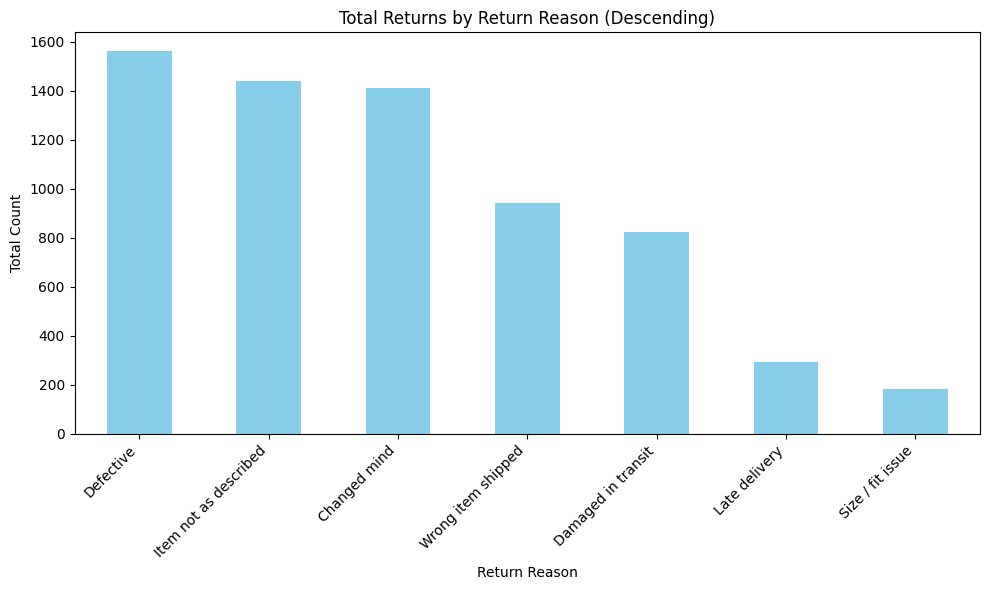

In [8]:


Returns_Reasons = df.groupby('return_reason').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
Returns_Reasons.plot(kind='bar', color='skyblue')
plt.title('Total Returns by Return Reason (Descending)')
plt.xlabel('Return Reason')
plt.ylabel('Total Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Returns Presented as cost

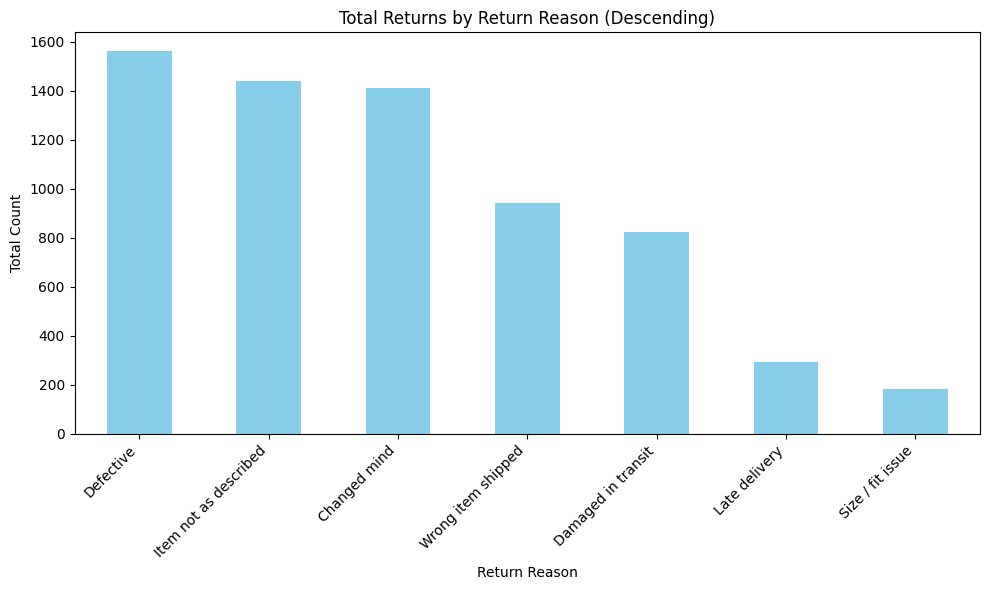

In [9]:
Returns_Reasons = df['return_reason'].value_counts()

plt.figure(figsize=(10, 6))
Returns_Reasons.plot(kind='bar', color='skyblue')
plt.title('Total Returns by Return Reason (Descending)')
plt.xlabel('Return Reason')
plt.ylabel('Total Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now to Look at Reviews sheet

In [10]:
df = pd.read_csv(DATA + 'vw_join_orders_reviews.csv')

In [11]:
df.head(30)

,order_id,customer_id,order_status,acquisition_channel,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_creation_date,review_answer_timestamp
0,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,Direct,NaN,10/28/2016,a93139d9d1314158c080e3db7e79618b,1.0,10/29/2016 0:00:00,10/30/2016 1:47:48
1,1aecadf4362edaca7fa033e882076c8d,e81a9f176936e3124dfd90c483bf3289,canceled,Direct,NaN,11/24/2016,faeda271ac0422948a70e0dd3df69553,2.0,11/26/2016 0:00:00,11/28/2016 17:37:44
2,2e32dea8a4d1ae5499a67674b387bc6a,7fd973e7865ee210512c6222d387e7aa,delivered,Direct,10/27/2016 14:02:34,11/28/2016,9d4df583085fec1900dfac4efd0b085a,1.0,10/28/2016 0:00:00,10/31/2016 5:02:55
3,5204d67853f827d1ee32810bf8f2d6c2,3dc7eb6da6c008460353d9a171e8fe6d,delivered,Direct,10/13/2016 15:45:44,11/28/2016,faf9ce3802b882a10bcd548f421ea9ff,5.0,10/18/2016 0:00:00,10/19/2016 19:15:49
4,88130f20a472f28fcca9dd5d50358820,8eff66e5b7c425dfbbe9a2cbf0f3883f,delivered,Direct,10/18/2016 22:57:42,11/28/2016,6a760d6d7c876b76f77353f24d9c14fa,5.0,10/19/2016 0:00:00,11/4/2016 9:08:50
5,2825848807f070485f0f0ef3829758f4,b30a4d09f171b5da553bab49a0a61764,delivered,Direct,10/17/2016 12:03:19,11/30/2016,984ab9fb9c9785407beb46bc068974e2,5.0,10/19/2016 0:00:00,10/20/2016 1:46:12
6,ed83f6065ae47112c8cfbd22e231b6d8,39f51cf31b3d2266b99005da1b5d5b79,invoiced,Direct,NaN,11/30/2016,3b850443ee703ff8381534dc0349847d,1.0,12/2/2016 0:00:00,12/6/2016 14:47:09
7,d743f434cc2921729af830ce00d474b3,407136bd5649e73981dce394b201897d,delivered,Direct,10/24/2016 18:13:49,11/30/2016,b8b1e3d3475e57893affe9798daad68d,3.0,10/25/2016 0:00:00,10/28/2016 0:50:19
8,45973912e490866800c0aea8f63099c8,912f108a7026f25f99240a5c4c60e2c3,shipped,Direct,NaN,12/1/2016,d7486b4da781b9d7dc5484ce65868081,1.0,12/3/2016 0:00:00,12/5/2016 10:33:35
9,3379d980824f0aa5dab057f2530759bb,17e6d37366dc8c8865588b0d1740d606,delivered,Direct,10/19/2016 4:01:59,12/2/2016,b977b767d10b380552343a815b19a490,5.0,10/25/2016 0:00:00,10/26/2016 0:31:56


Distribution of scores

In [12]:
print(df['review_score'].value_counts())
print("\n")
print(df['review_score'].describe())

review_score
5.0    57328
4.0    19142
1.0    11424
3.0     8179
2.0     3151
Name: count, dtype: int64


count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64


Get a feel for score values - 14.7% chance of a score 1-2

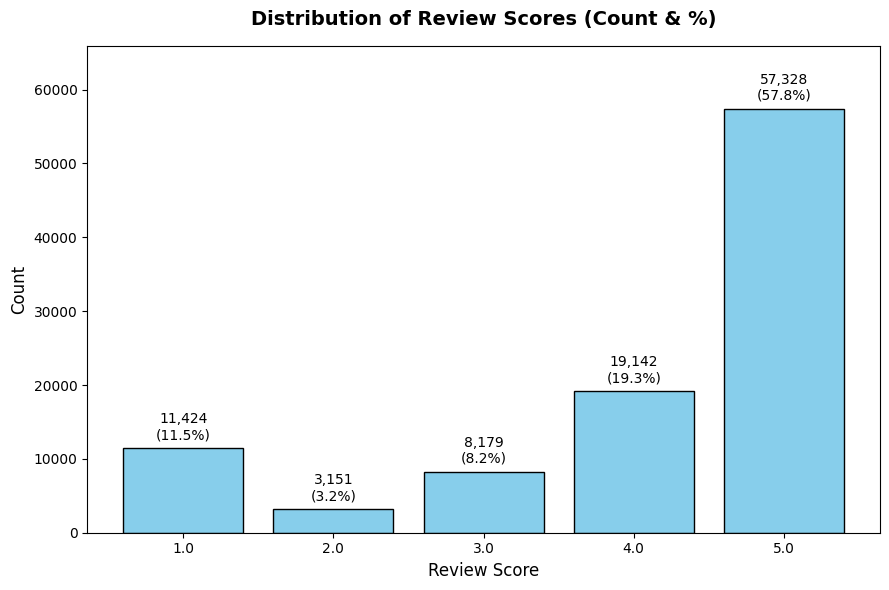

In [13]:

# Get counts and percentages
score_counts = df['review_score'].value_counts().sort_index()
total_reviews = len(df['review_score'].dropna())
score_pcts = (score_counts / total_reviews) * 100

# Plot bar chart
plt.figure(figsize=(9, 6))
bars = plt.bar(score_counts.index.astype(str), score_counts.values, color='skyblue', edgecolor='black')

# Add values and percentages above each bar
for bar, count, pct in zip(bars, score_counts.values, score_pcts.values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + (max(score_counts.values) * 0.015),
        f'{count:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Distribution of Review Scores (Count & %)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ylim(0, max(score_counts.values) * 1.15)  # Make room for text labels
plt.tight_layout()
plt.show()